In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

In [2]:
DATA_DIR = "/kaggle/input/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign"   
IMG_SIZE = 48
NUM_CLASSES = 43
BATCH_SIZE = 64
EPOCHS = 25
RANDOM_STATE = 42

In [24]:
print(os.listdir(DATA_DIR))

['Meta', 'meta', 'Meta.csv', 'Train.csv', 'Test.csv', 'Test', 'test', 'Train', 'train']


In [3]:
def load_images(df, data_dir, img_size=IMG_SIZE):
    images, labels = [], []
    paths = df["Path"].values
    class_ids = df["ClassId"].values

    for path, class_id in zip(paths, class_ids):
        img_path = os.path.join(data_dir, path)
        img = cv2.imread(img_path)

        if img is None:
            continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (img_size, img_size))
        images.append(img)
        labels.append(class_id)

    return np.array(images), np.array(labels)

In [4]:
train_df = pd.read_csv(os.path.join(DATA_DIR, "Train.csv"))
test_df = pd.read_csv(os.path.join(DATA_DIR, "Test.csv"))
meta_df = pd.read_csv(os.path.join(DATA_DIR, "Meta.csv"))

In [5]:
GTSRB_CLASS_NAMES = {
    0: "Speed limit 20", 1: "Speed limit 30", 2: "Speed limit 50", 3: "Speed limit 60",
    4: "Speed limit 70", 5: "Speed limit 80", 6: "End speed limit 80", 7: "Speed limit 100",
    8: "Speed limit 120", 9: "No passing", 10: "No passing >3.5t", 11: "Right-of-way junction",
    12: "Priority road", 13: "Yield", 14: "Stop", 15: "No vehicles", 16: "No vehicles >3.5t",
    17: "No entry", 18: "General caution", 19: "Dangerous curve left", 20: "Dangerous curve right",
    21: "Double curve", 22: "Bumpy road", 23: "Slippery road", 24: "Road narrows right",
    25: "Road work", 26: "Traffic signals", 27: "Pedestrians", 28: "Children crossing",
    29: "Bicycles crossing", 30: "Beware ice/snow", 31: "Wild animals crossing",
    32: "End speed+passing limits", 33: "Turn right ahead", 34: "Turn left ahead",
    35: "Ahead only", 36: "Go straight or right", 37: "Go straight or left",
    38: "Keep right", 39: "Keep left", 40: "Roundabout mandatory", 41: "End of no passing",
    42: "End no passing >3.5t"
}
CLASS_NAMES = {i: GTSRB_CLASS_NAMES.get(i, str(i)) for i in range(NUM_CLASSES)}

In [6]:
X_train_full, y_train_full = load_images(train_df, DATA_DIR)
X_test, y_test = load_images(test_df, DATA_DIR)
print(f"Train shape: {X_train_full.shape}, Test shape: {X_test.shape}")

Train shape: (39209, 48, 48, 3), Test shape: (12630, 48, 48, 3)


In [7]:
fig, axes = plt.subplots(5, 9, figsize=(18, 10))
axes = axes.flatten()
for i, row in meta_df.iterrows():
    img_path = os.path.join(DATA_DIR, row["Path"])
    img = cv2.imread(img_path)
    if img is None:
        continue
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    axes[i].imshow(img)
    axes[i].set_title(f'{row["ClassId"]}: {CLASS_NAMES.get(row["ClassId"], "")}', fontsize=6)
    axes[i].axis("off")
for j in range(i + 1, len(axes)):
    axes[j].axis("off")
plt.tight_layout()
plt.savefig("meta_class_samples.png", dpi=120)
plt.close()

In [8]:
X_train_full = X_train_full.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

y_train_full_int = y_train_full.copy()  

X_train, X_val, y_train_int, y_val_int = train_test_split(
    X_train_full, y_train_full_int,
    test_size=0.2, random_state=RANDOM_STATE, stratify=y_train_full_int
)

y_train_cat = to_categorical(y_train_int, NUM_CLASSES)
y_val_cat = to_categorical(y_val_int, NUM_CLASSES)
y_test_cat = to_categorical(y_test, NUM_CLASSES)

In [9]:
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train_int),
    y=y_train_int
)
class_weight_dict = dict(enumerate(class_weights))

In [10]:
datagen = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
)
datagen.fit(X_train)

In [11]:
model = models.Sequential([
        layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
        layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),
        layers.Dropout(0.3),
        layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),
        layers.Dropout(0.3),
        layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),
        layers.Dropout(0.4),
        layers.Flatten(),
        layers.Dense(512, activation="relu", kernel_regularizer=regularizers.l2(0.0005)),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(NUM_CLASSES, activation="softmax")
    ])


I0000 00:00:1784435801.847179      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1784435801.850031      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [12]:
model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 12, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 2,672,715 (10.20 MB)

 Trainable params: 2,670,795 (10.19 MB)

 Non-trainable params: 1,920 (7.50 KB)

In [13]:
callbacks = [
    EarlyStopping(patience=10, restore_best_weights=True, monitor="val_accuracy"),
    ReduceLROnPlateau(factor=0.5, patience=4, monitor="val_loss", min_lr=1e-6),
    ModelCheckpoint("best_model.keras", save_best_only=True, monitor="val_accuracy")
]

history = model.fit(
    datagen.flow(X_train, y_train_cat, batch_size=BATCH_SIZE),
    validation_data=(X_val, y_val_cat),
    epochs=EPOCHS,
    class_weight=class_weight_dict,
    callbacks=callbacks
)

Epoch 1/25
  4/491 ━━━━━━━━━━━━━━━━━━━━ 22s 46ms/step - accuracy: 0.0270 - loss: 5.8288 

I0000 00:00:1784435825.024605     134 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


491/491 ━━━━━━━━━━━━━━━━━━━━ 50s 76ms/step - accuracy: 0.3450 - loss: 2.9198 - val_accuracy: 0.6809 - val_loss: 1.5973 - learning_rate: 0.0010
Epoch 2/25
491/491 ━━━━━━━━━━━━━━━━━━━━ 27s 56ms/step - accuracy: 0.7466 - loss: 1.3025 - val_accuracy: 0.9448 - val_loss: 0.7881 - learning_rate: 0.0010
Epoch 3/25
491/491 ━━━━━━━━━━━━━━━━━━━━ 27s 55ms/step - accuracy: 0.8863 - loss: 0.8683 - val_accuracy: 0.9760 - val_loss: 0.6141 - learning_rate: 0.0010
Epoch 4/25
491/491 ━━━━━━━━━━━━━━━━━━━━ 27s 55ms/step - accuracy: 0.9347 - loss: 0.6657 - val_accuracy: 0.9717 - val_loss: 0.5500 - learning_rate: 0.0010
Epoch 5/25
491/491 ━━━━━━━━━━━━━━━━━━━━ 27s 56ms/step - accuracy: 0.9510 - loss: 0.5559 - val_accuracy: 0.9930 - val_loss: 0.4464 - learning_rate: 0.0010
Epoch 6/25
491/491 ━━━━━━━━━━━━━━━━━━━━ 27s 55ms/step - accuracy: 0.9565 - loss: 0.5289 - val_accuracy: 0.9923 - val_loss: 0.4399 - learning_rate: 0.0010
Epoch 7/25
491/491 ━━━━━━━━━━━━━━━━━━━━ 27s 55ms/step - accuracy: 0.9601 - loss: 0.5218

In [27]:
acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]

loss = history.history["loss"]
val_loss = history.history["val_loss"]

epochs = range(1, len(acc) + 1)

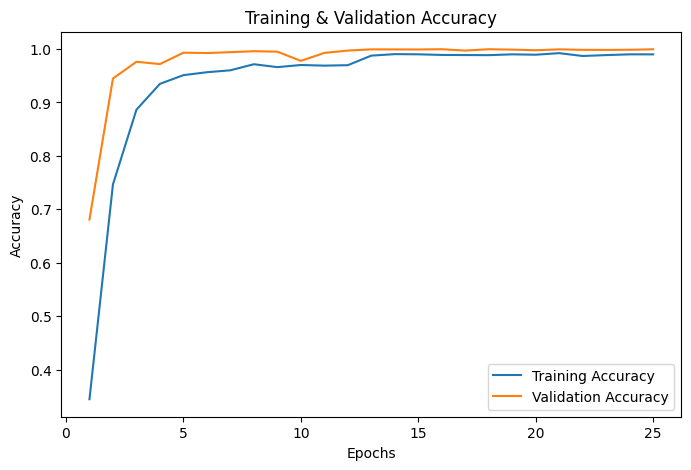

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(epochs, acc, label="Training Accuracy")
plt.plot(epochs, val_acc, label="Validation Accuracy")
plt.title("Training & Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

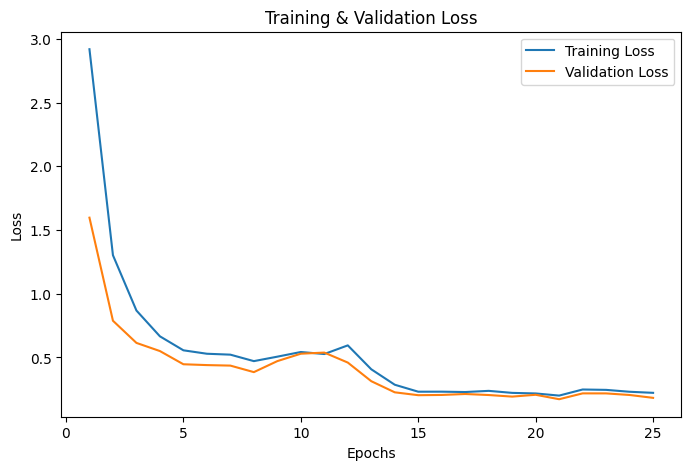

In [29]:
plt.figure(figsize=(8,5))
plt.plot(epochs, loss, label="Training Loss")
plt.plot(epochs, val_loss, label="Validation Loss")
plt.title("Training & Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [39]:
y_prob = model.predict(X_test)
y_pred = np.argmax(y_prob, axis=1)
y_true = y_test
test_acc = (y_pred == y_true).mean()
print(f"Test Accuracy: {test_acc:.4f}")

395/395 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
Test Accuracy: 0.9842


In [40]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        60
           1       1.00      0.99      0.99       720
           2       0.99      1.00      1.00       750
           3       1.00      0.98      0.99       450
           4       1.00      0.99      1.00       660
           5       0.98      1.00      0.99       630
           6       1.00      0.95      0.98       150
           7       1.00      1.00      1.00       450
           8       1.00      1.00      1.00       450
           9       0.99      1.00      1.00       480
          10       1.00      0.99      1.00       660
          11       0.99      1.00      1.00       420
          12       1.00      0.95      0.98       690
          13       1.00      1.00      1.00       720
          14       0.92      1.00      0.96       270
          15       1.00      1.00      1.00       210
          16       1.00      1.00      1.00       150
          17       1.00    